In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from keras.models import Sequential
from keras.layers import LSTM, Dense


In [4]:
# Load the sample dataset
df = pd.read_csv('../dataset.csv', parse_dates=['datetime'])

# Check basic info
df.info()
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 8 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   datetime               datetime64[ns]
 1   Global_active_power    float64       
 2   Global_reactive_power  float64       
 3   Voltage                float64       
 4   Global_intensity       float64       
 5   Sub_metering_1         float64       
 6   Sub_metering_2         float64       
 7   Sub_metering_3         float64       
dtypes: datetime64[ns](1), float64(7)
memory usage: 126.7 MB


,datetime,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [5]:
# Convert datetime to index
df.set_index('datetime', inplace=True)

# Resample to hourly mean
df_hourly = df.resample('H').mean()

# Drop rows with NaN (caused by resampling empty hours)
df_hourly.dropna(inplace=True)

df_hourly.head()


C:\Users\HP\AppData\Local\Temp\ipykernel_9136\473146643.py:5: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_hourly = df.resample('H').mean()


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,
2006-12-16 17:00:00,4.222889,0.229000,234.643889,18.100000,0.0,0.527778,16.861111
2006-12-16 18:00:00,3.632200,0.080033,234.580167,15.600000,0.0,6.716667,16.866667
2006-12-16 19:00:00,3.400233,0.085233,233.232500,14.503333,0.0,1.433333,16.683333
2006-12-16 20:00:00,3.268567,0.075100,234.071500,13.916667,0.0,0.000000,16.783333
2006-12-16 21:00:00,3.056467,0.076667,237.158667,13.046667,0.0,0.416667,17.216667


In [6]:
# We'll predict Global_active_power
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df_hourly)

# For inverse transform later
target_scaler = MinMaxScaler()
target_scaler.fit(df_hourly[['Global_active_power']])


MinMaxScaler()

In [7]:
def create_dataset(data, time_step=24):  # 1-day lookback
    X, y = [], []
    for i in range(len(data) - time_step):
        X.append(data[i:i + time_step])
        y.append(data[i + time_step][0])  # Target: Global_active_power
    return np.array(X), np.array(y)



In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense
from tensorflow.keras.optimizers import Adam, RMSprop, SGD, Nadam, Adamax
combos = [
    {'time_step': 30, 'units': 64, 'dropout': 0.2, 'batch_size': 32, 'epochs': 20, 'optimizer': 'adam'},
    {'time_step': 60, 'units': 128, 'dropout': 0.2, 'batch_size': 64, 'epochs': 30, 'optimizer': 'adam'},
    {'time_step': 60, 'units': 100, 'dropout': 0.3, 'batch_size': 32, 'epochs': 25, 'optimizer': 'rmsprop'},
    {'time_step': 90, 'units': 128, 'dropout': 0.1, 'batch_size': 64, 'epochs': 20, 'optimizer': 'nadam'},
    {'time_step': 45, 'units': 64, 'dropout': 0.25, 'batch_size': 32, 'epochs': 40, 'optimizer': 'adam'},
    {'time_step': 60, 'units': 256, 'dropout': 0.2, 'batch_size': 64, 'epochs': 30, 'optimizer': 'adamax'},
    {'time_step': 30, 'units': 128, 'dropout': 0.3, 'batch_size': 16, 'epochs': 50, 'optimizer': SGD(learning_rate=0.01)}
]

results = []

for i, cfg in enumerate(combos):
    print(f"\nTraining Combo {i+1}/{len(combos)}: {cfg}")
    
    # Create dataset
    X, y = create_dataset(scaled_data, cfg['time_step'])
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

    # Build model
    model = Sequential()
    model.add(LSTM(cfg['units'], return_sequences=False, input_shape=(X_train.shape[1], X_train.shape[2])))
    model.add(Dropout(cfg['dropout']))
    model.add(Dense(1))

    model.compile(loss='mean_squared_error', optimizer=cfg['optimizer'])
    model.fit(X_train, y_train, epochs=cfg['epochs'], batch_size=cfg['batch_size'], verbose=0)

    # Predict and evaluate
    y_pred = model.predict(X_test)
    y_test_rescaled = scaler.inverse_transform(np.concatenate((y_test.reshape(-1,1), np.zeros((len(y_test), X.shape[2]-1))), axis=1))[:,0]
    y_pred_rescaled = scaler.inverse_transform(np.concatenate((y_pred, np.zeros((len(y_pred), X.shape[2]-1))), axis=1))[:,0]

    mse = mean_squared_error(y_test_rescaled, y_pred_rescaled)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_rescaled, y_pred_rescaled)
    r2 = r2_score(y_test_rescaled, y_pred_rescaled)

    results.append({
        'Combo': f'C{i+1}',
        'R2 Score': r2,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'Params': cfg
    })

# Sort and display results
df_results = pd.DataFrame(results).sort_values(by='R2 Score', ascending=False)
print("\n📊 Results Sorted by R² Score:\n")
print(df_results[['Combo', 'R2 Score', 'MSE', 'RMSE', 'MAE']])


Training Combo 1/7: {'time_step': 30, 'units': 64, 'dropout': 0.2, 'batch_size': 32, 'epochs': 20, 'optimizer': 'adam'}
214/214 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

Training Combo 2/7: {'time_step': 60, 'units': 128, 'dropout': 0.2, 'batch_size': 64, 'epochs': 30, 'optimizer': 'adam'}


C:\Users\HP\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


214/214 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step

Training Combo 3/7: {'time_step': 60, 'units': 100, 'dropout': 0.3, 'batch_size': 32, 'epochs': 25, 'optimizer': 'rmsprop'}


C:\Users\HP\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


214/214 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step

Training Combo 4/7: {'time_step': 90, 'units': 128, 'dropout': 0.1, 'batch_size': 64, 'epochs': 20, 'optimizer': 'nadam'}


C:\Users\HP\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


213/213 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step

Training Combo 5/7: {'time_step': 45, 'units': 64, 'dropout': 0.25, 'batch_size': 32, 'epochs': 40, 'optimizer': 'adam'}


C:\Users\HP\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


214/214 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step

Training Combo 6/7: {'time_step': 60, 'units': 256, 'dropout': 0.2, 'batch_size': 64, 'epochs': 30, 'optimizer': 'adamax'}


C:\Users\HP\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [26]:
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]


In [33]:
model = Sequential()
model.add((LSTM(256, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2]))))
model.add(Dropout(0.2))
model.add(LSTM(128, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=20, batch_size=128, validation_split=0.1)


C:\Users\HP\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 115s 562ms/step - loss: 0.0184 - val_loss: 0.0103
Epoch 2/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 103s 538ms/step - loss: 0.0100 - val_loss: 0.0096
Epoch 3/20
  3/192 ━━━━━━━━━━━━━━━━━━━━ 1:29 473ms/step - loss: 0.0107

KeyboardInterrupt: 

In [28]:
y_pred = model.predict(X_test)

# Reshape and inverse scale
y_pred_rescaled = target_scaler.inverse_transform(y_pred.reshape(-1, 1))
y_test_rescaled = target_scaler.inverse_transform(y_test.reshape(-1, 1))


214/214 ━━━━━━━━━━━━━━━━━━━━ 9s 37ms/step


In [29]:
if not np.isnan(y_test_rescaled).any() and not np.isnan(y_pred_rescaled).any():
    mse = mean_squared_error(y_test_rescaled, y_pred_rescaled)
    print(f"Mean Squared Error: {mse:.3f}")
else:
    print("NaN values detected! Evaluation skipped.")


Mean Squared Error: 0.266


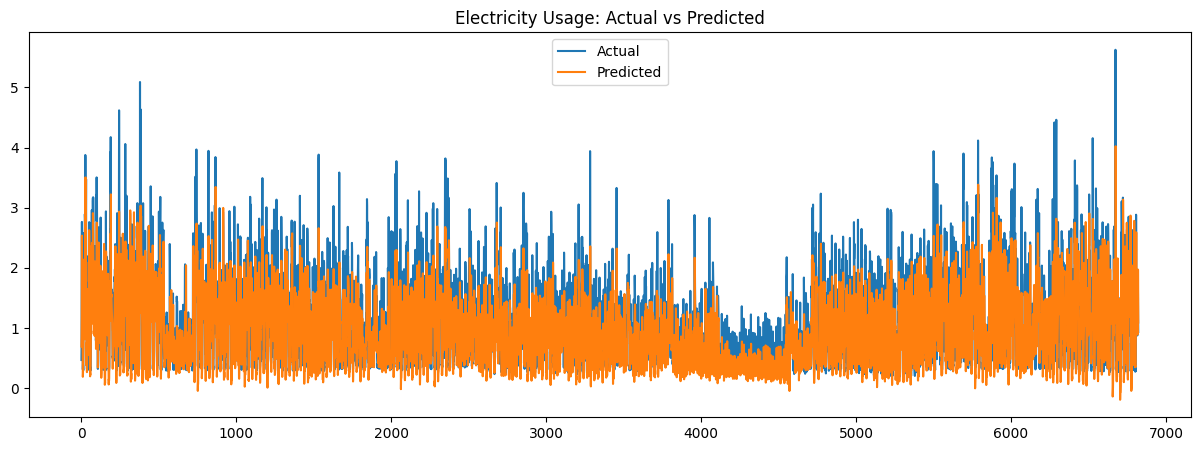

In [30]:
plt.figure(figsize=(15, 5))
plt.plot(y_test_rescaled, label='Actual')
plt.plot(y_pred_rescaled, label='Predicted')
plt.title('Electricity Usage: Actual vs Predicted')
plt.legend()
plt.show()


In [31]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Compute metrics
mse = mean_squared_error(y_test_rescaled, y_pred_rescaled)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_rescaled, y_pred_rescaled)
r2 = r2_score(y_test_rescaled, y_pred_rescaled)

# Print results
print(f"📊 Evaluation Metrics:")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R² Score: {r2:.4f}")


📊 Evaluation Metrics:
Mean Squared Error (MSE): 0.2661
Root Mean Squared Error (RMSE): 0.5158
Mean Absolute Error (MAE): 0.3598
R² Score: 0.5193
